1. Markdown title: 04 - Harmonic Decline DCA
2. Imports
3. DATA_FILE / OUTPUT_DIR
4. Load and clean df
5. Build median_curve
6. Define harmonic functions
7. Fit median harmonic model
8. Continue comparison

# 04 - Harmonic Decline DCA

In this section, we evaluate harmonic decline.

Harmonic decline is a special case of hyperbolic decline where:

b = 1

The harmonic decline equation is:

q(t) = qi / (1 + Di * t)

Where:

- q(t) is production at time t
- qi is the fitted initial production rate
- Di is the fitted initial decline rate

Why this matters:

Harmonic decline is more flexible than exponential decline because the effective decline rate decreases over time.

But it is less flexible than general hyperbolic decline because `b` is fixed at 1 instead of estimated from the data.

We will use the same structure as before:

- Fit harmonic decline to the median type curve
- Compare median harmonic against exponential and hyperbolic
- Fit harmonic decline separately for each well
- Compare per-well harmonic forecasts against previous DCA models

In [26]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [28]:
DATA_FILE = Path(
    r"C:\Users\tawac\Documents\SEM UT at Dallas Program"
    r"\SEM_JD_Market_Research_2026-06-17"
    r"\portfolio\permian_type_curve"
    r"\data\processed\martin_selected_30_monthly_production_normalized.csv"
)

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

In [30]:
df = pd.read_csv(
    DATA_FILE,
    dtype={
        "api8": str,
        "lease_no": str,
        "district": str,
    },
)

numeric_columns = [
    "month_on_production",
    "oil_bbl",
    "casinghead_gas_mcf",
    "boe",
    "interval_length_proxy_ft",
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df = df.sort_values(["api8", "month_on_production"]).reset_index(drop=True)

df.head()

,api8,district,lease_no,well_no,lease_name,operator_name,field_name,first_prod_month,cycle_year_month,month_on_production,oil_bbl,casinghead_gas_mcf,boe,interval_length_proxy_ft,reported_first_month,first_positive_prod_month,reported_month_on_production
0,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202201,1,27270.0,26374.0,31665.666667,10036.0,202201,202201,1
1,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202202,2,25100.0,24522.0,29187.000000,10036.0,202201,202201,2
2,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202203,3,22589.0,23927.0,26576.833333,10036.0,202201,202201,3
3,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202204,4,18960.0,20036.0,22299.333333,10036.0,202201,202201,4
4,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202205,5,18050.0,17744.0,21007.333333,10036.0,202201,202201,5


In [32]:
median_curve = (
    df[df["month_on_production"].between(1, 33)]
    .groupby("month_on_production", as_index=False)
    .agg(median_oil_bbl=("oil_bbl", "median"))
)

median_curve

,month_on_production,median_oil_bbl
0,1,12627.5
1,2,29502.5
2,3,22872.5
3,4,18845.5
4,5,17784.5
5,6,14556.0
6,7,13961.0
7,8,10253.5
8,9,8815.5
9,10,8958.5


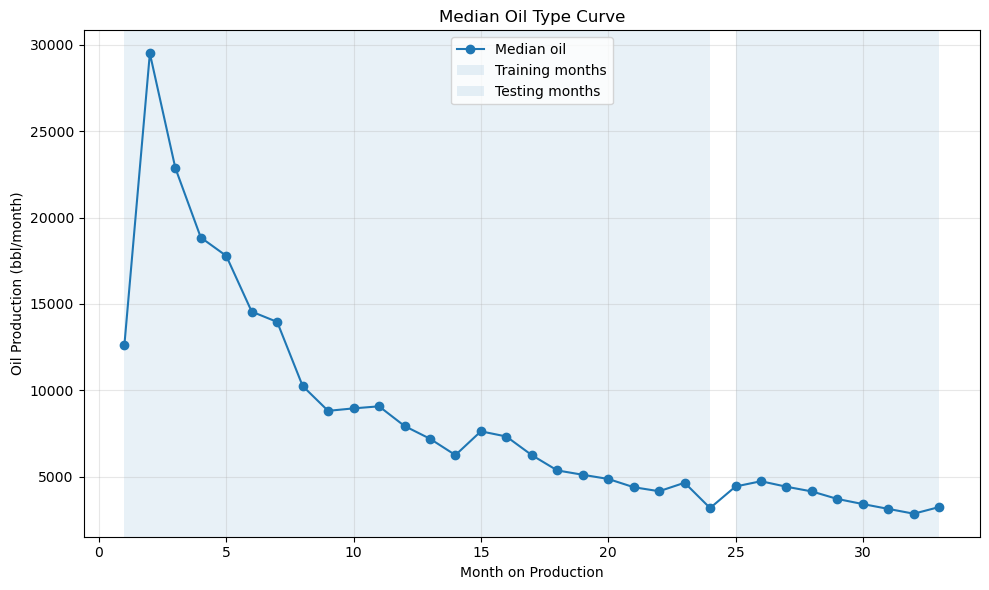

In [34]:
plt.figure(figsize=(10, 6))

plt.plot(
    median_curve["month_on_production"],
    median_curve["median_oil_bbl"],
    marker="o",
    label="Median oil",
)

plt.axvspan(1, 24, alpha=0.10, label="Training months")
plt.axvspan(25, 33, alpha=0.10, label="Testing months")

plt.title("Median Oil Type Curve")
plt.xlabel("Month on Production")
plt.ylabel("Oil Production (bbl/month)")
plt.legend()
plt.grid(True, alpha=0.30)
plt.tight_layout()
plt.show()

In [44]:
def predict_harmonic(months, qi, di):
    months = np.asarray(months, dtype=float)

    return qi / (1 + di * months)

In [38]:
def harmonic_sse_for_di(fit_data, month_column, rate_column, di):
    adjusted_log_rates = (
        np.log(fit_data[rate_column])
        + np.log(1 + di * fit_data[month_column])
    )

    log_qi = adjusted_log_rates.mean()
    qi = np.exp(log_qi)

    fitted_rates = predict_harmonic(
        fit_data[month_column],
        qi,
        di,
    )

    sse = np.sum(
        (np.log(fit_data[rate_column]) - np.log(fitted_rates)) ** 2
    )

    return sse, qi

In [46]:
def fit_harmonic_decline(
    curve,
    month_column,
    rate_column,
    start_month=2,
    end_month=24,
):
    fit_data = curve[curve[month_column].between(start_month, end_month)].copy()
    fit_data = fit_data[fit_data[rate_column] > 0].copy()

    best_sse = np.inf
    best_qi = None
    best_di = None

    di_grid = np.linspace(0.001, 0.400, 400)

    for di in di_grid:
        sse, qi = harmonic_sse_for_di(
            fit_data,
            month_column,
            rate_column,
            di,
        )

        if sse < best_sse:
            best_sse = sse
            best_qi = qi
            best_di = di

    return best_qi, best_di, fit_data, best_sse

In [48]:
median_harm_qi, median_harm_di, median_harm_fit_data, median_harm_sse = fit_harmonic_decline(
    median_curve,
    month_column="month_on_production",
    rate_column="median_oil_bbl",
    start_month=2,
    end_month=24,
)

print(f"Fitted qi: {median_harm_qi:,.0f} bbl/month")
print(f"Fitted Di: {median_harm_di:.4f} per month")
print(f"Fitted Di: {median_harm_di * 100:.2f}% per month")
print(f"Log-space SSE: {median_harm_sse:.4f}")

Fitted qi: 46,206 bbl/month
Fitted Di: 0.4000 per month
Fitted Di: 40.00% per month
Log-space SSE: 0.2980


In [50]:
plot_months = np.arange(1, 34)

median_curve["harmonic_fit_oil_bbl"] = predict_harmonic(
    plot_months,
    median_harm_qi,
    median_harm_di,
)

median_curve

,month_on_production,median_oil_bbl,harmonic_fit_oil_bbl
0,1,12627.5,33004.295970
1,2,29502.5,25670.007977
2,3,22872.5,21002.733799
3,4,18845.5,17771.543984
4,5,17784.5,15402.004786
5,6,14556.0,13590.004223
6,7,13961.0,12159.477463
7,8,10253.5,11001.431990
8,9,8815.5,10044.785730
9,10,8958.5,9241.202872


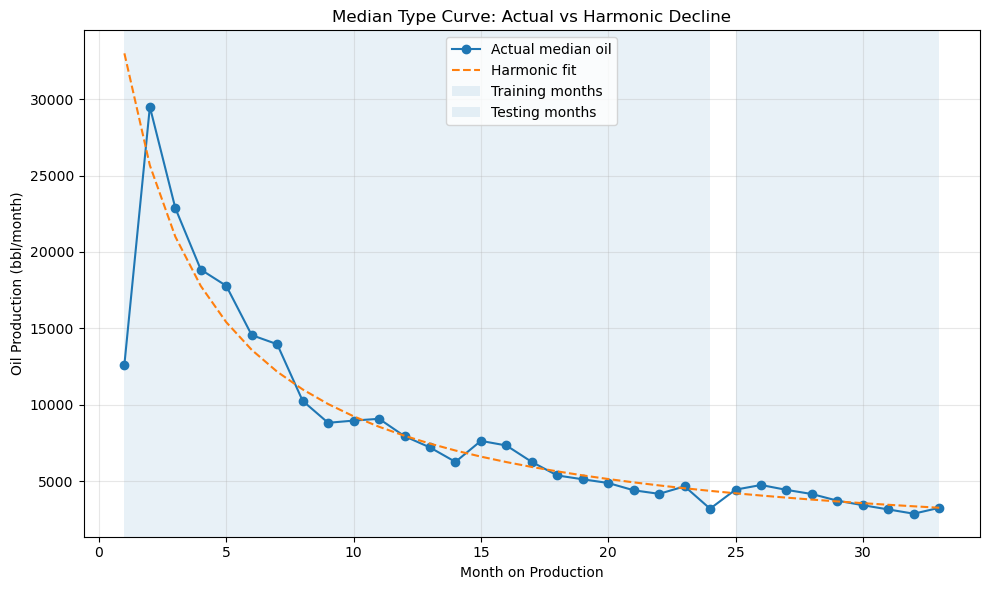

In [52]:
plt.figure(figsize=(10, 6))

plt.plot(
    median_curve["month_on_production"],
    median_curve["median_oil_bbl"],
    marker="o",
    label="Actual median oil",
)

plt.plot(
    median_curve["month_on_production"],
    median_curve["harmonic_fit_oil_bbl"],
    linestyle="--",
    label="Harmonic fit",
)

plt.axvspan(1, 24, alpha=0.10, label="Training months")
plt.axvspan(25, 33, alpha=0.10, label="Testing months")

plt.title("Median Type Curve: Actual vs Harmonic Decline")
plt.xlabel("Month on Production")
plt.ylabel("Oil Production (bbl/month)")
plt.legend()
plt.grid(True, alpha=0.30)
plt.tight_layout()
plt.show()

In [54]:
def calculate_error_metrics(curve, prediction_column):
    metric_rows = []

    for window_name, start_month, end_month in [
        ("train", 2, 24),
        ("test", 25, 33),
    ]:
        window_data = curve[
            curve["month_on_production"].between(start_month, end_month)
        ].copy()

        actual = window_data["median_oil_bbl"]
        predicted = window_data[prediction_column]

        error = predicted - actual

        mae = error.abs().mean()
        rmse = np.sqrt((error ** 2).mean())
        bias = error.mean()

        smape = (
            np.abs(predicted - actual)
            / ((np.abs(actual) + np.abs(predicted)) / 2)
        ).mean() * 100

        metric_rows.append(
            {
                "model": "harmonic_decline",
                "window": window_name,
                "start_month": start_month,
                "end_month": end_month,
                "observations": len(window_data),
                "mae_bbl": mae,
                "rmse_bbl": rmse,
                "bias_bbl": bias,
                "smape_percent": smape,
            }
        )

    return pd.DataFrame(metric_rows)

In [56]:
harmonic_metrics = calculate_error_metrics(
    median_curve,
    prediction_column="harmonic_fit_oil_bbl",
)

harmonic_metrics

,model,window,start_month,end_month,observations,mae_bbl,rmse_bbl,bias_bbl,smape_percent
0,harmonic_decline,train,2,24,23,927.018585,1263.888264,-378.789576,9.366639
1,harmonic_decline,test,25,33,9,308.470371,375.887785,-102.198059,8.077890


In [58]:
harmonic_fit_summary = pd.DataFrame(
    [
        {
            "curve_name": "median_type_curve",
            "fit_start_month": 2,
            "fit_end_month": 24,
            "qi_bbl_per_month": median_harm_qi,
            "di_per_month": median_harm_di,
            "di_percent_per_month": median_harm_di * 100,
            "b_factor": 1.0,
            "log_space_sse": median_harm_sse,
        }
    ]
)

median_curve.to_csv(
    OUTPUT_DIR / "median_harmonic_decline_curve.csv",
    index=False,
)

harmonic_metrics.to_csv(
    OUTPUT_DIR / "harmonic_decline_metrics.csv",
    index=False,
)

harmonic_fit_summary.to_csv(
    OUTPUT_DIR / "harmonic_decline_fit_summary.csv",
    index=False,
)

harmonic_fit_summary

,curve_name,fit_start_month,fit_end_month,qi_bbl_per_month,di_per_month,di_percent_per_month,b_factor,log_space_sse
0,median_type_curve,2,24,46206.014358,0.4,40.0,1.0,0.297997


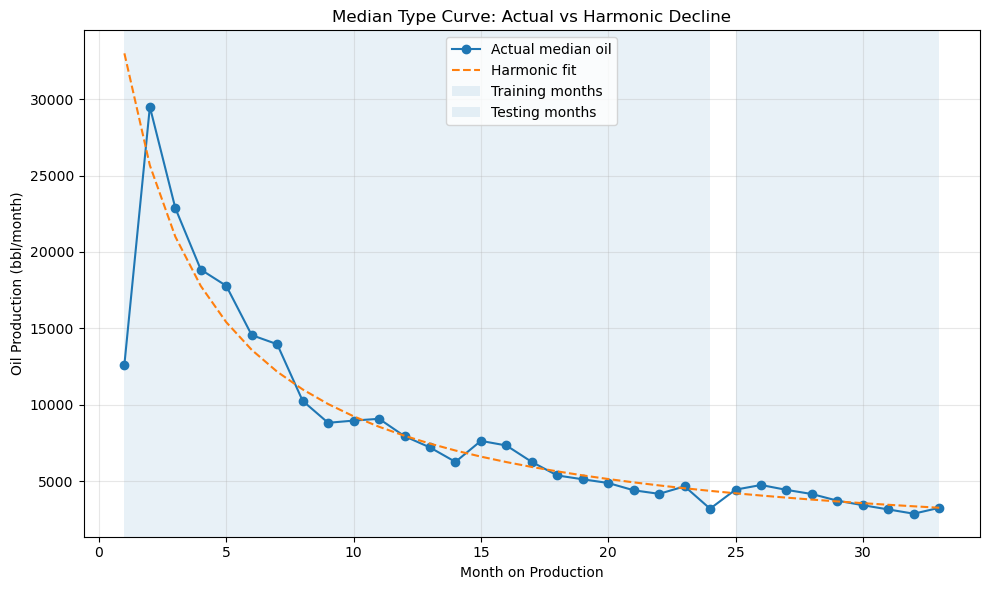

In [60]:
plt.figure(figsize=(10, 6))

plt.plot(
    median_curve["month_on_production"],
    median_curve["median_oil_bbl"],
    marker="o",
    label="Actual median oil",
)

plt.plot(
    median_curve["month_on_production"],
    median_curve["harmonic_fit_oil_bbl"],
    linestyle="--",
    label="Harmonic fit",
)

plt.axvspan(1, 24, alpha=0.10, label="Training months")
plt.axvspan(25, 33, alpha=0.10, label="Testing months")

plt.title("Median Type Curve: Actual vs Harmonic Decline")
plt.xlabel("Month on Production")
plt.ylabel("Oil Production (bbl/month)")
plt.legend()
plt.grid(True, alpha=0.30)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "median_harmonic_decline_fit.png",
    dpi=150,
)

plt.show()

## Median Harmonic DCA Checkpoint

We fit a harmonic decline model to the median oil type curve.

Fit setup:

- Curve: median monthly oil production
- Fit window: months 2-24
- Test window: months 25-33
- Month 1 was not used for fitting because it may represent partial first-month production.

Model form:

q(t) = qi / (1 + Di * t)

Interpretation:

Harmonic decline is a special case of hyperbolic decline where `b = 1`.

This means harmonic decline has fewer fitted parameters than hyperbolic decline, but it is still more flexible than exponential decline because the effective decline rate decreases over time.

Early observation:

The median harmonic curve should be compared against exponential and hyperbolic decline before deciding whether the fixed `b = 1` assumption is useful for this cohort.

In [66]:
exponential_metrics = pd.read_csv(
    OUTPUT_DIR / "per_well_exponential_dca_results.csv"
)

hyperbolic_metrics_saved = pd.read_csv(
    OUTPUT_DIR / "hyperbolic_decline_metrics.csv"
)

harmonic_metrics_saved = pd.read_csv(
    OUTPUT_DIR / "harmonic_decline_metrics.csv"
)

hyperbolic_metrics_saved, harmonic_metrics_saved

(                model window  start_month  end_month  observations  \
 0  hyperbolic_decline  train            2         24            23   
 1  hyperbolic_decline   test           25         33             9   
 
       mae_bbl    rmse_bbl    bias_bbl  smape_percent  
 0  580.480364  741.042712  -28.182542       7.067301  
 1  515.677533  611.221072 -498.402604      13.690890  ,
               model window  start_month  end_month  observations     mae_bbl  \
 0  harmonic_decline  train            2         24            23  927.018585   
 1  harmonic_decline   test           25         33             9  308.470371   
 
       rmse_bbl    bias_bbl  smape_percent  
 0  1263.888264 -378.789576       9.366639  
 1   375.887785 -102.198059       8.077890  )


## Per-Well Harmonic DCA

The median type curve gives a cohort-level view, but each well may decline differently.

In this section, we fit a separate harmonic decline model to each well.

Setup:

- Fit window: months 12-24
- Forecast-check window: months 25-33
- Target: monthly oil production
- Model: harmonic decline

We use months 12-24 for fitting because early production can be noisy, and the later fit window better reflects stabilized decline behavior.

Harmonic decline is equivalent to hyperbolic decline with `b = 1`, so this section tests whether a fixed harmonic shape performs well at the individual-well level.

In [68]:
PER_WELL_FIT_START_MONTH = 12
PER_WELL_FIT_END_MONTH = 24

FORECAST_START_MONTH = 25
FORECAST_END_MONTH = 33

In [70]:
per_well_harm_results = []
per_well_harm_forecasts = []
skipped_harm_wells = []

for api8, well_data in df.groupby("api8"):
    well_curve = well_data[
        well_data["month_on_production"].between(1, FORECAST_END_MONTH)
    ].copy()

    fit_window_data = well_curve[
        well_curve["month_on_production"].between(
            PER_WELL_FIT_START_MONTH,
            PER_WELL_FIT_END_MONTH,
        )
    ].copy()

    forecast_data = well_curve[
        well_curve["month_on_production"].between(
            FORECAST_START_MONTH,
            FORECAST_END_MONTH,
        )
    ].copy()

    if len(fit_window_data) < 6:
        skipped_harm_wells.append(
            {
                "api8": api8,
                "reason": "fewer_than_6_fit_months",
                "fit_rows": len(fit_window_data),
                "forecast_rows": len(forecast_data),
            }
        )
        continue

    if len(forecast_data) == 0:
        skipped_harm_wells.append(
            {
                "api8": api8,
                "reason": "no_forecast_months",
                "fit_rows": len(fit_window_data),
                "forecast_rows": len(forecast_data),
            }
        )
        continue

    if (fit_window_data["oil_bbl"] > 0).sum() < 6:
        skipped_harm_wells.append(
            {
                "api8": api8,
                "reason": "fewer_than_6_positive_fit_months",
                "fit_rows": len(fit_window_data),
                "forecast_rows": len(forecast_data),
            }
        )
        continue

    try:
        qi, di, fit_data, sse = fit_harmonic_decline(
            well_curve,
            month_column="month_on_production",
            rate_column="oil_bbl",
            start_month=PER_WELL_FIT_START_MONTH,
            end_month=PER_WELL_FIT_END_MONTH,
        )
    except Exception as error:
        skipped_harm_wells.append(
            {
                "api8": api8,
                "reason": f"fit_error: {error}",
                "fit_rows": len(fit_window_data),
                "forecast_rows": len(forecast_data),
            }
        )
        continue

    forecast_data["harmonic_forecast_oil_bbl"] = predict_harmonic(
        forecast_data["month_on_production"],
        qi,
        di,
    )

    actual_test_oil_bbl = forecast_data["oil_bbl"].sum()
    forecast_test_oil_bbl = forecast_data["harmonic_forecast_oil_bbl"].sum()

    if actual_test_oil_bbl == 0:
        skipped_harm_wells.append(
            {
                "api8": api8,
                "reason": "zero_actual_test_oil",
                "fit_rows": len(fit_window_data),
                "forecast_rows": len(forecast_data),
            }
        )
        continue

    error_bbl = forecast_test_oil_bbl - actual_test_oil_bbl
    percent_error = error_bbl / actual_test_oil_bbl * 100

    per_well_harm_results.append(
        {
            "api8": api8,
            "lease_name": well_curve["lease_name"].iloc[0],
            "well_no": well_curve["well_no"].iloc[0],
            "fit_start_month": PER_WELL_FIT_START_MONTH,
            "fit_end_month": PER_WELL_FIT_END_MONTH,
            "forecast_start_month": FORECAST_START_MONTH,
            "forecast_end_month": FORECAST_END_MONTH,
            "qi_bbl_per_month": qi,
            "di_per_month": di,
            "di_percent_per_month": di * 100,
            "b_factor": 1.0,
            "log_space_sse": sse,
            "actual_test_oil_bbl": actual_test_oil_bbl,
            "forecast_test_oil_bbl": forecast_test_oil_bbl,
            "error_bbl": error_bbl,
            "percent_error": percent_error,
        }
    )

    per_well_harm_forecasts.append(forecast_data)
    

In [72]:
len(per_well_harm_results), len(skipped_harm_wells)

(30, 0)

In [74]:
per_well_harm_results_df = pd.DataFrame(per_well_harm_results)

per_well_harm_results_df = (
    per_well_harm_results_df
    .sort_values("percent_error")
    .reset_index(drop=True)
)

per_well_harm_results_df["absolute_percent_error"] = (
    per_well_harm_results_df["percent_error"].abs()
)

per_well_harm_results_df

,api8,lease_name,well_no,fit_start_month,fit_end_month,forecast_start_month,forecast_end_month,qi_bbl_per_month,di_per_month,di_percent_per_month,b_factor,log_space_sse,actual_test_oil_bbl,forecast_test_oil_bbl,error_bbl,percent_error,absolute_percent_error
0,31743757,GLYNN-ATCHISON 44M,213H,12,24,25,33,5939.838839,0.068,6.8,1.0,2.508884,35704.0,18050.566057,-17653.433943,-49.443855,49.443855
1,31744055,DAVIS-LACY 31K,211H,12,24,25,33,42274.629829,0.400,40.0,1.0,1.659161,49251.0,30401.491026,-18849.508974,-38.272338,38.272338
2,31744057,DAVIS-LACY 31I,209H,12,24,25,33,56101.366229,0.400,40.0,1.0,1.191285,55854.0,40344.887437,-15509.112563,-27.767237,27.767237
3,31744070,DAVIS-LACY 31C,203H,12,24,25,33,23833.286173,0.400,40.0,1.0,1.303496,22233.0,17139.533536,-5093.466464,-22.909488,22.909488
4,31743755,GLYNN-ATCHISON 44N,214H,12,24,25,33,54286.567828,0.400,40.0,1.0,1.673092,46559.0,39039.788433,-7519.211567,-16.149856,16.149856
5,31744053,EPLEY-MARTIN 31D,104H,12,24,25,33,43267.790523,0.400,40.0,1.0,1.064360,36143.0,31115.715279,-5027.284721,-13.909428,13.909428
6,31744782,FORTUNE-ASHLEY 31M,213H,12,24,25,33,43038.409189,0.400,40.0,1.0,0.565042,34514.0,30950.757369,-3563.242631,-10.324050,10.324050
7,31744059,DAVIS-LACY 31G,207H,12,24,25,33,37336.106852,0.400,40.0,1.0,0.249037,28855.0,26849.988326,-2005.011674,-6.948576,6.948576
8,31744061,EPLEY-MARTIN 31C,103H,12,24,25,33,61066.926623,0.400,40.0,1.0,0.536105,46336.0,43915.833898,-2420.166102,-5.223079,5.223079
9,31744051,EPLEY-MARTIN 31E,105H,12,24,25,33,5704.680697,0.001,0.1,1.0,12.674832,51711.0,49895.480599,-1815.519401,-3.510896,3.510896


In [76]:
per_well_harm_forecast_df = pd.concat(
    per_well_harm_forecasts,
    ignore_index=True,
)

per_well_harm_forecast_df.head()

,api8,district,lease_no,well_no,lease_name,operator_name,field_name,first_prod_month,cycle_year_month,month_on_production,oil_bbl,casinghead_gas_mcf,boe,interval_length_proxy_ft,reported_first_month,first_positive_prod_month,reported_month_on_production,harmonic_forecast_oil_bbl
0,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202401,25,2639.0,15643.0,5246.166667,10036.0,202201,202201,25,4855.954964
1,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202402,26,2580.0,17013.0,5415.500000,10036.0,202201,202201,26,4685.570579
2,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202403,27,3901.0,4562.0,4661.333333,10036.0,202201,202201,27,4526.737678
3,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202404,28,4403.0,4124.0,5090.333333,10036.0,202201,202201,28,4378.320049
4,31743171,10,56651,4H,BOHANAN-BLOCKER 3B,"PIONEER NATURAL RES. USA, INC.",SPRABERRY (TREND AREA),202201,202405,29,4712.0,5720.0,5665.333333,10036.0,202201,202201,29,4239.325762


In [78]:
per_well_harm_error_summary = pd.DataFrame(
    [
        {
            "model": "harmonic_decline",
            "wells_fit": len(per_well_harm_results_df),
            "mean_absolute_percent_error": per_well_harm_results_df["absolute_percent_error"].mean(),
            "median_absolute_percent_error": per_well_harm_results_df["absolute_percent_error"].median(),
            "mean_percent_error": per_well_harm_results_df["percent_error"].mean(),
            "median_percent_error": per_well_harm_results_df["percent_error"].median(),
            "mean_di_percent_per_month": per_well_harm_results_df["di_percent_per_month"].mean(),
            "median_di_percent_per_month": per_well_harm_results_df["di_percent_per_month"].median(),
            "min_di_percent_per_month": per_well_harm_results_df["di_percent_per_month"].min(),
            "max_di_percent_per_month": per_well_harm_results_df["di_percent_per_month"].max(),
        }
    ]
)

per_well_harm_error_summary

,model,wells_fit,mean_absolute_percent_error,median_absolute_percent_error,mean_percent_error,median_percent_error,mean_di_percent_per_month,median_di_percent_per_month,min_di_percent_per_month,max_di_percent_per_month
0,harmonic_decline,30,33.006547,15.097784,19.46456,7.0457,28.12,40.0,0.1,40.0


In [80]:
per_well_harm_results_df.to_csv(
    OUTPUT_DIR / "per_well_harmonic_dca_results.csv",
    index=False,
)

per_well_harm_error_summary.to_csv(
    OUTPUT_DIR / "per_well_harmonic_dca_error_summary.csv",
    index=False,
)

per_well_harm_forecast_df.to_csv(
    OUTPUT_DIR / "per_well_harmonic_dca_monthly_forecasts.csv",
    index=False,
)

In [82]:
best_harm_fit_api8s = (
    per_well_harm_results_df
    .sort_values("absolute_percent_error")
    .head(3)["api8"]
    .tolist()
)

worst_harm_fit_api8s = (
    per_well_harm_results_df
    .sort_values("absolute_percent_error", ascending=False)
    .head(3)["api8"]
    .tolist()
)

best_harm_fit_api8s, worst_harm_fit_api8s

(['31744072', '31744052', '31744067'], ['31743549', '31744069', '31743568'])

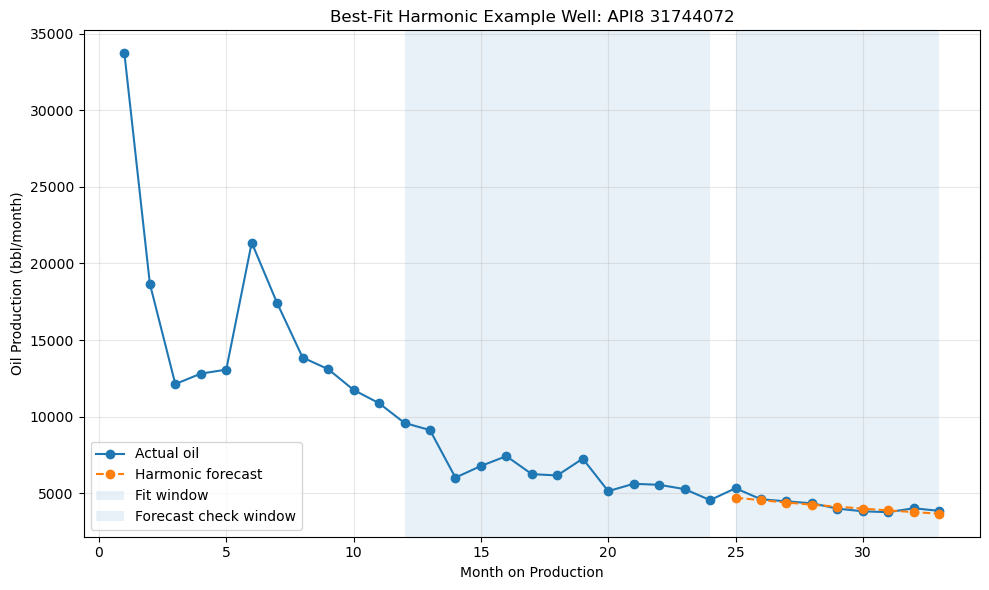

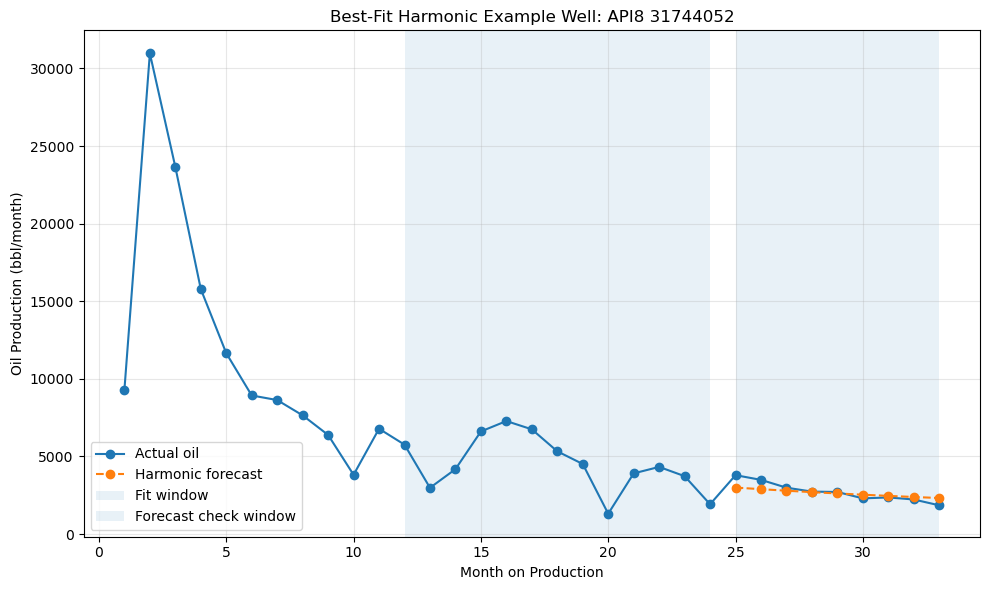

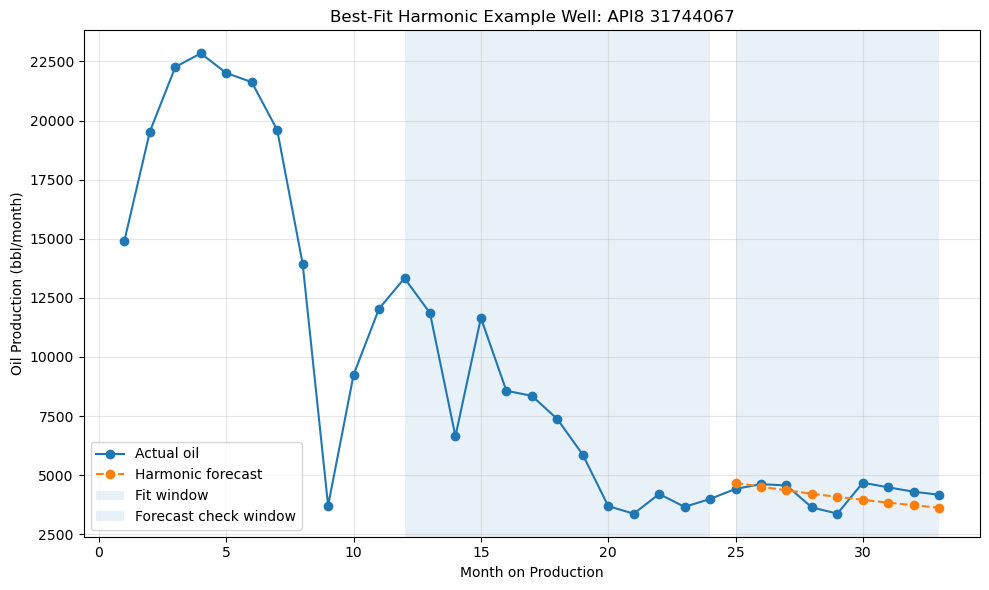

In [84]:
for api8 in best_harm_fit_api8s:
    well_history = df[
        (df["api8"] == api8)
        & (df["month_on_production"].between(1, 33))
    ].copy()

    well_forecast = per_well_harm_forecast_df[
        per_well_harm_forecast_df["api8"] == api8
    ].copy()

    plt.figure(figsize=(10, 6))

    plt.plot(
        well_history["month_on_production"],
        well_history["oil_bbl"],
        marker="o",
        label="Actual oil",
    )

    plt.plot(
        well_forecast["month_on_production"],
        well_forecast["harmonic_forecast_oil_bbl"],
        marker="o",
        linestyle="--",
        label="Harmonic forecast",
    )

    plt.axvspan(12, 24, alpha=0.10, label="Fit window")
    plt.axvspan(25, 33, alpha=0.10, label="Forecast check window")

    plt.title(f"Best-Fit Harmonic Example Well: API8 {api8}")
    plt.xlabel("Month on Production")
    plt.ylabel("Oil Production (bbl/month)")
    plt.legend()
    plt.grid(True, alpha=0.30)
    plt.tight_layout()
    plt.show()

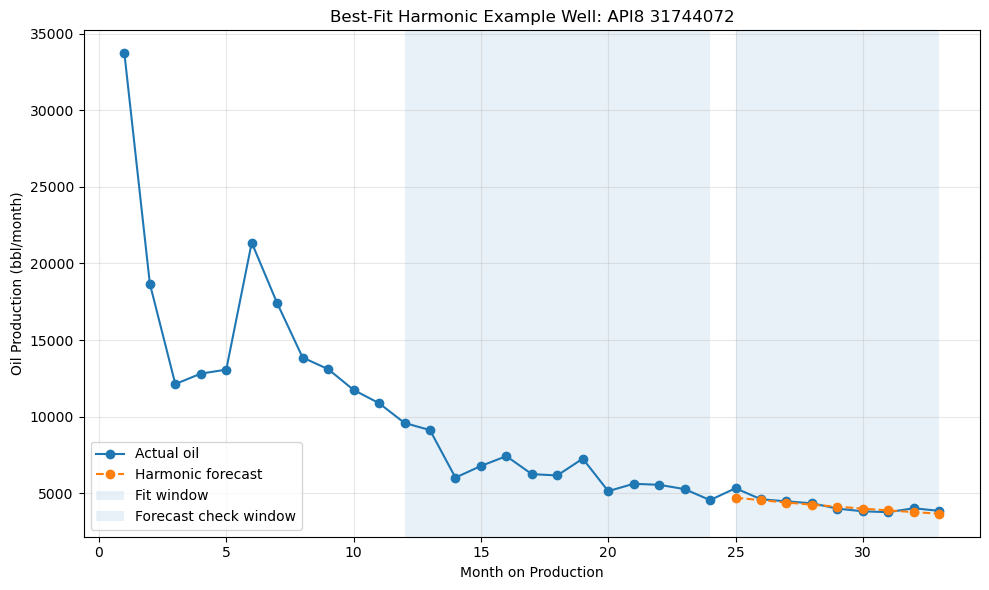

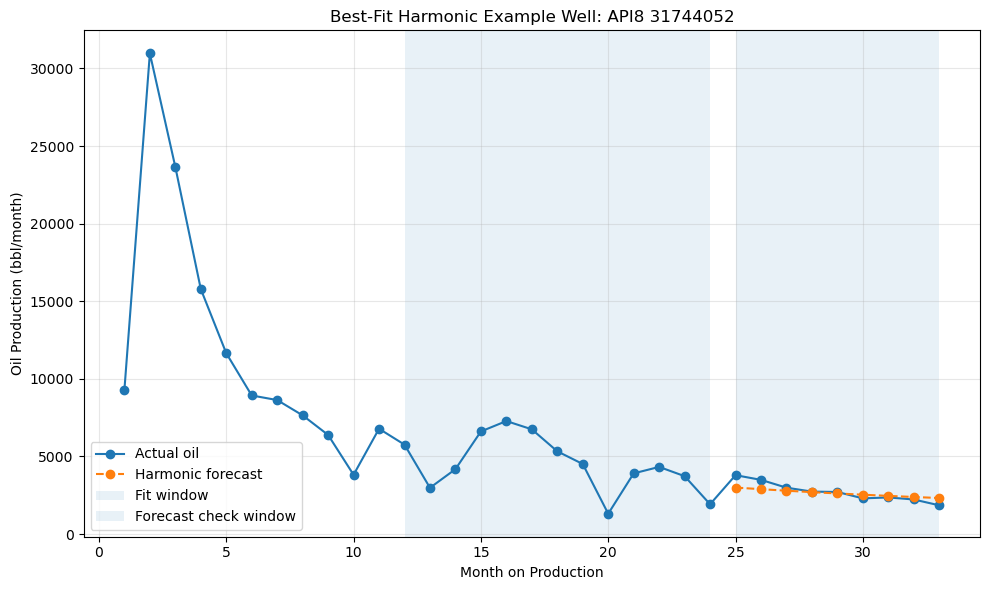

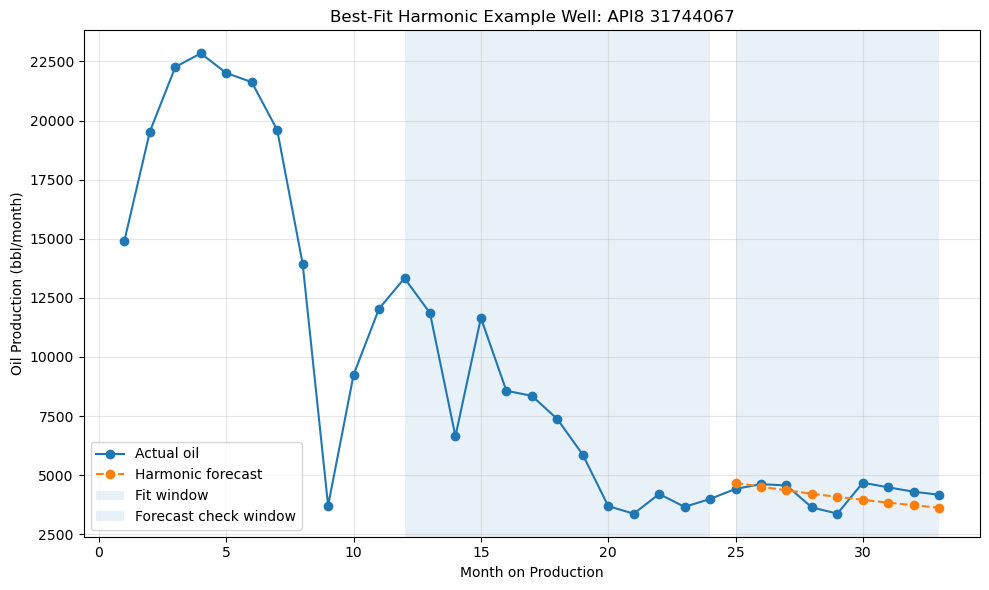

In [86]:
for api8 in best_harm_fit_api8s:
    well_history = df[
        (df["api8"] == api8)
        & (df["month_on_production"].between(1, 33))
    ].copy()

    well_forecast = per_well_harm_forecast_df[
        per_well_harm_forecast_df["api8"] == api8
    ].copy()

    plt.figure(figsize=(10, 6))

    plt.plot(
        well_history["month_on_production"],
        well_history["oil_bbl"],
        marker="o",
        label="Actual oil",
    )

    plt.plot(
        well_forecast["month_on_production"],
        well_forecast["harmonic_forecast_oil_bbl"],
        marker="o",
        linestyle="--",
        label="Harmonic forecast",
    )

    plt.axvspan(12, 24, alpha=0.10, label="Fit window")
    plt.axvspan(25, 33, alpha=0.10, label="Forecast check window")

    plt.title(f"Best-Fit Harmonic Example Well: API8 {api8}")
    plt.xlabel("Month on Production")
    plt.ylabel("Oil Production (bbl/month)")
    plt.legend()
    plt.grid(True, alpha=0.30)
    plt.tight_layout()
    plt.show()

In [88]:
example_harm_well_groups = pd.DataFrame(
    {
        "best_fit_api8": pd.Series(best_harm_fit_api8s),
        "worst_fit_api8": pd.Series(worst_harm_fit_api8s),
    }
)

example_harm_well_groups

,best_fit_api8,worst_fit_api8
0,31744072,31743549
1,31744052,31744069
2,31744067,31743568


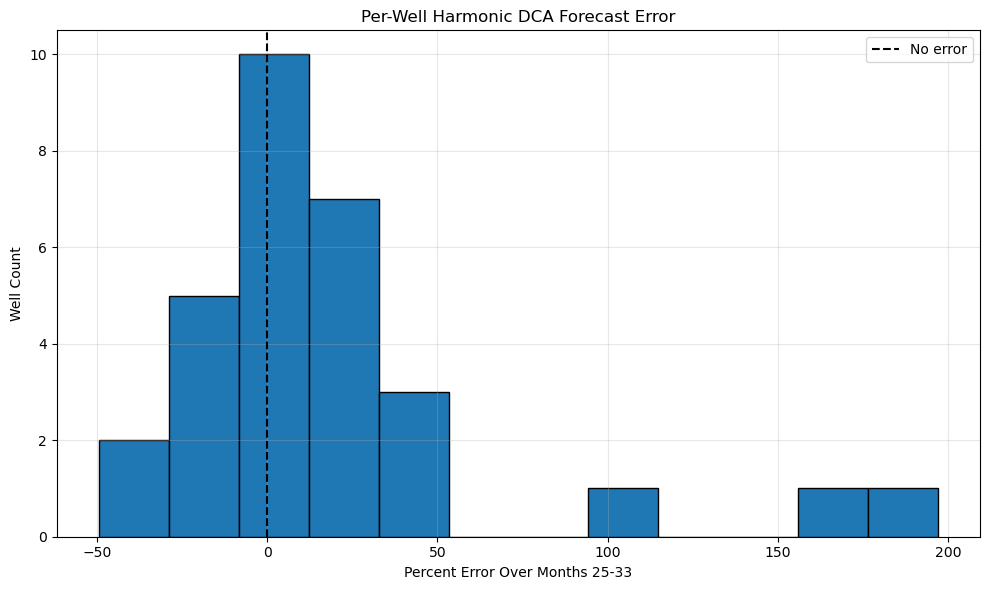

In [90]:
plt.figure(figsize=(10, 6))

plt.hist(
    per_well_harm_results_df["percent_error"],
    bins=12,
    edgecolor="black",
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    label="No error",
)

plt.title("Per-Well Harmonic DCA Forecast Error")
plt.xlabel("Percent Error Over Months 25-33")
plt.ylabel("Well Count")
plt.legend()
plt.grid(True, alpha=0.30)
plt.tight_layout()
plt.show()

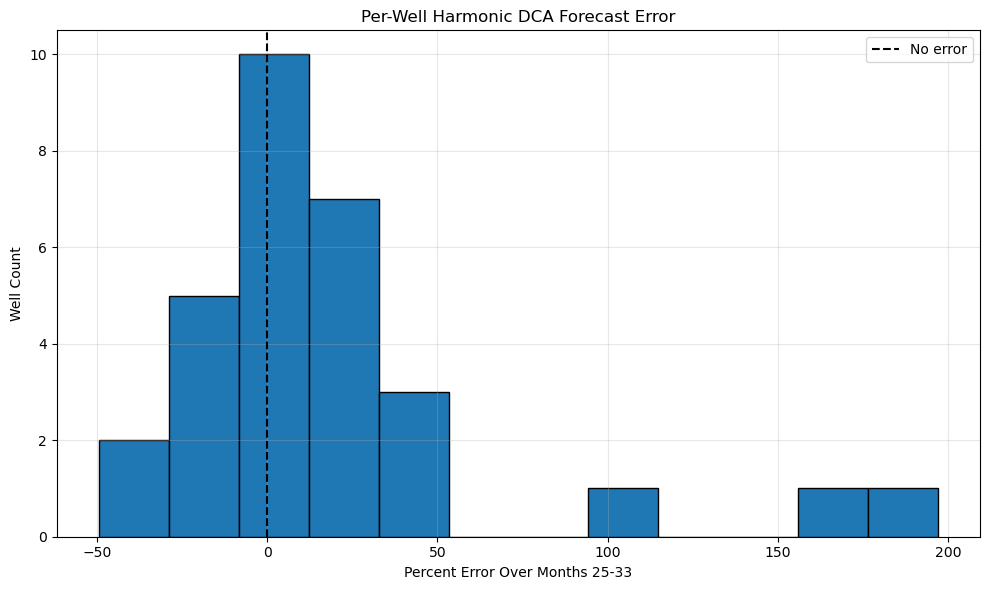

In [92]:
plt.figure(figsize=(10, 6))

plt.hist(
    per_well_harm_results_df["percent_error"],
    bins=12,
    edgecolor="black",
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    label="No error",
)

plt.title("Per-Well Harmonic DCA Forecast Error")
plt.xlabel("Percent Error Over Months 25-33")
plt.ylabel("Well Count")
plt.legend()
plt.grid(True, alpha=0.30)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "per_well_harmonic_dca_forecast_error.png",
    dpi=150,
)

plt.show()

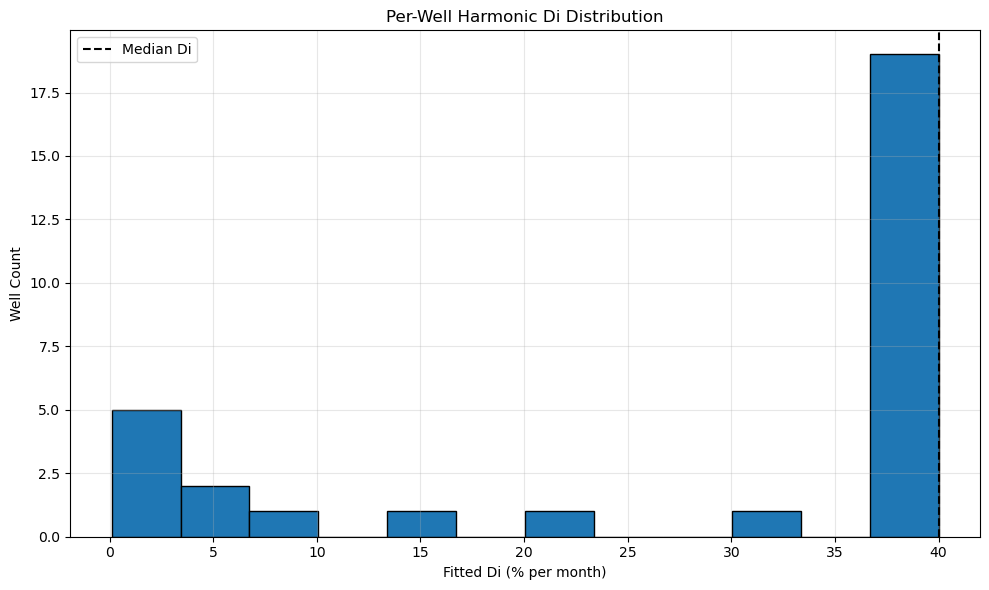

In [94]:
plt.figure(figsize=(10, 6))

plt.hist(
    per_well_harm_results_df["di_percent_per_month"],
    bins=12,
    edgecolor="black",
)

plt.axvline(
    per_well_harm_results_df["di_percent_per_month"].median(),
    color="black",
    linestyle="--",
    label="Median Di",
)

plt.title("Per-Well Harmonic Di Distribution")
plt.xlabel("Fitted Di (% per month)")
plt.ylabel("Well Count")
plt.legend()
plt.grid(True, alpha=0.30)
plt.tight_layout()
plt.show()

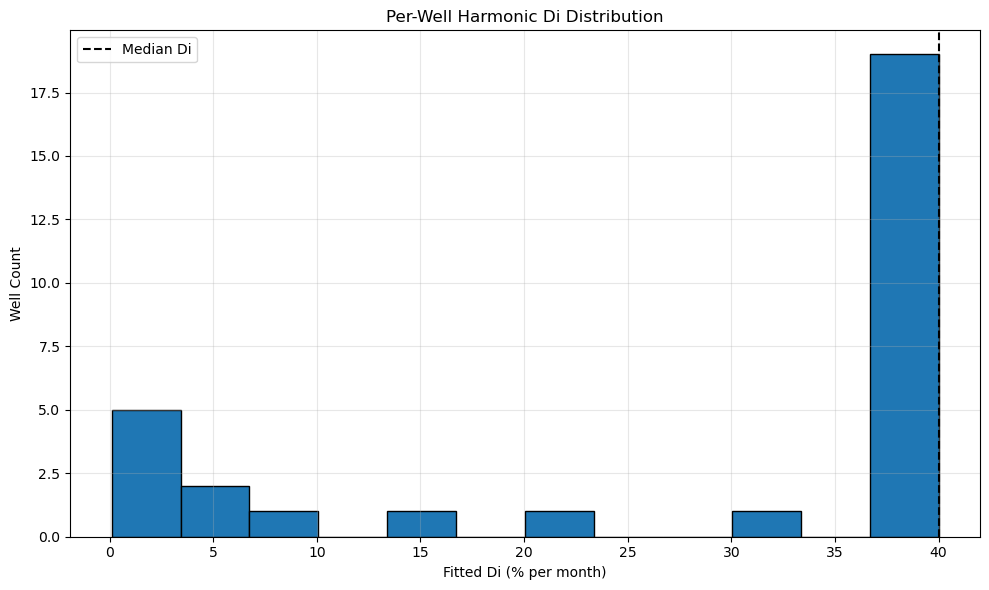

In [96]:
plt.figure(figsize=(10, 6))

plt.hist(
    per_well_harm_results_df["di_percent_per_month"],
    bins=12,
    edgecolor="black",
)

plt.axvline(
    per_well_harm_results_df["di_percent_per_month"].median(),
    color="black",
    linestyle="--",
    label="Median Di",
)

plt.title("Per-Well Harmonic Di Distribution")
plt.xlabel("Fitted Di (% per month)")
plt.ylabel("Well Count")
plt.legend()
plt.grid(True, alpha=0.30)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "per_well_harmonic_di_distribution.png",
    dpi=150,
)

plt.show()

In [98]:
per_well_harm_comparison_ready = per_well_harm_results_df[
    [
        "api8",
        "lease_name",
        "well_no",
        "actual_test_oil_bbl",
        "forecast_test_oil_bbl",
        "error_bbl",
        "percent_error",
        "absolute_percent_error",
        "qi_bbl_per_month",
        "di_per_month",
        "di_percent_per_month",
        "b_factor",
    ]
].copy()

per_well_harm_comparison_ready = per_well_harm_comparison_ready.rename(
    columns={
        "forecast_test_oil_bbl": "harmonic_forecast_test_oil_bbl",
        "error_bbl": "harmonic_error_bbl",
        "percent_error": "harmonic_percent_error",
        "absolute_percent_error": "harmonic_absolute_percent_error",
        "qi_bbl_per_month": "harmonic_qi_bbl_per_month",
        "di_per_month": "harmonic_di_per_month",
        "di_percent_per_month": "harmonic_di_percent_per_month",
        "b_factor": "harmonic_b_factor",
    }
)

per_well_harm_comparison_ready

,api8,lease_name,well_no,actual_test_oil_bbl,harmonic_forecast_test_oil_bbl,harmonic_error_bbl,harmonic_percent_error,harmonic_absolute_percent_error,harmonic_qi_bbl_per_month,harmonic_di_per_month,harmonic_di_percent_per_month,harmonic_b_factor
0,31743757,GLYNN-ATCHISON 44M,213H,35704.0,18050.566057,-17653.433943,-49.443855,49.443855,5939.838839,0.068,6.8,1.0
1,31744055,DAVIS-LACY 31K,211H,49251.0,30401.491026,-18849.508974,-38.272338,38.272338,42274.629829,0.400,40.0,1.0
2,31744057,DAVIS-LACY 31I,209H,55854.0,40344.887437,-15509.112563,-27.767237,27.767237,56101.366229,0.400,40.0,1.0
3,31744070,DAVIS-LACY 31C,203H,22233.0,17139.533536,-5093.466464,-22.909488,22.909488,23833.286173,0.400,40.0,1.0
4,31743755,GLYNN-ATCHISON 44N,214H,46559.0,39039.788433,-7519.211567,-16.149856,16.149856,54286.567828,0.400,40.0,1.0
5,31744053,EPLEY-MARTIN 31D,104H,36143.0,31115.715279,-5027.284721,-13.909428,13.909428,43267.790523,0.400,40.0,1.0
6,31744782,FORTUNE-ASHLEY 31M,213H,34514.0,30950.757369,-3563.242631,-10.324050,10.324050,43038.409189,0.400,40.0,1.0
7,31744059,DAVIS-LACY 31G,207H,28855.0,26849.988326,-2005.011674,-6.948576,6.948576,37336.106852,0.400,40.0,1.0
8,31744061,EPLEY-MARTIN 31C,103H,46336.0,43915.833898,-2420.166102,-5.223079,5.223079,61066.926623,0.400,40.0,1.0
9,31744051,EPLEY-MARTIN 31E,105H,51711.0,49895.480599,-1815.519401,-3.510896,3.510896,5704.680697,0.001,0.1,1.0


In [100]:
per_well_harm_comparison_ready = per_well_harm_results_df[
    [
        "api8",
        "lease_name",
        "well_no",
        "actual_test_oil_bbl",
        "forecast_test_oil_bbl",
        "error_bbl",
        "percent_error",
        "absolute_percent_error",
        "qi_bbl_per_month",
        "di_per_month",
        "di_percent_per_month",
        "b_factor",
    ]
].copy()

per_well_harm_comparison_ready = per_well_harm_comparison_ready.rename(
    columns={
        "forecast_test_oil_bbl": "harmonic_forecast_test_oil_bbl",
        "error_bbl": "harmonic_error_bbl",
        "percent_error": "harmonic_percent_error",
        "absolute_percent_error": "harmonic_absolute_percent_error",
        "qi_bbl_per_month": "harmonic_qi_bbl_per_month",
        "di_per_month": "harmonic_di_per_month",
        "di_percent_per_month": "harmonic_di_percent_per_month",
        "b_factor": "harmonic_b_factor",
    }
)

per_well_harm_comparison_ready

,api8,lease_name,well_no,actual_test_oil_bbl,harmonic_forecast_test_oil_bbl,harmonic_error_bbl,harmonic_percent_error,harmonic_absolute_percent_error,harmonic_qi_bbl_per_month,harmonic_di_per_month,harmonic_di_percent_per_month,harmonic_b_factor
0,31743757,GLYNN-ATCHISON 44M,213H,35704.0,18050.566057,-17653.433943,-49.443855,49.443855,5939.838839,0.068,6.8,1.0
1,31744055,DAVIS-LACY 31K,211H,49251.0,30401.491026,-18849.508974,-38.272338,38.272338,42274.629829,0.400,40.0,1.0
2,31744057,DAVIS-LACY 31I,209H,55854.0,40344.887437,-15509.112563,-27.767237,27.767237,56101.366229,0.400,40.0,1.0
3,31744070,DAVIS-LACY 31C,203H,22233.0,17139.533536,-5093.466464,-22.909488,22.909488,23833.286173,0.400,40.0,1.0
4,31743755,GLYNN-ATCHISON 44N,214H,46559.0,39039.788433,-7519.211567,-16.149856,16.149856,54286.567828,0.400,40.0,1.0
5,31744053,EPLEY-MARTIN 31D,104H,36143.0,31115.715279,-5027.284721,-13.909428,13.909428,43267.790523,0.400,40.0,1.0
6,31744782,FORTUNE-ASHLEY 31M,213H,34514.0,30950.757369,-3563.242631,-10.324050,10.324050,43038.409189,0.400,40.0,1.0
7,31744059,DAVIS-LACY 31G,207H,28855.0,26849.988326,-2005.011674,-6.948576,6.948576,37336.106852,0.400,40.0,1.0
8,31744061,EPLEY-MARTIN 31C,103H,46336.0,43915.833898,-2420.166102,-5.223079,5.223079,61066.926623,0.400,40.0,1.0
9,31744051,EPLEY-MARTIN 31E,105H,51711.0,49895.480599,-1815.519401,-3.510896,3.510896,5704.680697,0.001,0.1,1.0


In [102]:
per_well_harm_comparison_ready.to_csv(
    OUTPUT_DIR / "per_well_harmonic_comparison_ready.csv",
    index=False,
)

## Per-Well Harmonic DCA Checkpoint

We completed the first per-well harmonic decline workflow.

Method:

- Each well was fit separately using monthly oil production.
- The fitting window was months 12-24.
- The forecast-check window was months 25-33.
- Forecast error was calculated by comparing forecasted oil to actual oil over months 25-33.
- Harmonic decline was treated as the fixed-`b = 1` case of hyperbolic decline.

Outputs created:

- `per_well_harmonic_dca_results.csv`
- `per_well_harmonic_dca_error_summary.csv`
- `per_well_harmonic_dca_monthly_forecasts.csv`
- `example_best_and_worst_harmonic_dca_wells.csv`
- `per_well_harmonic_dca_forecast_error.png`
- `per_well_harmonic_di_distribution.png`
- `per_well_harmonic_comparison_ready.csv`

Interpretation:

The harmonic model is more flexible than exponential decline because its effective decline rate decreases over time.

However, it is less flexible than full hyperbolic decline because it fixes the `b` factor at 1 rather than estimating it separately for each well.

This makes harmonic decline a useful middle-ground benchmark between exponential decline and full hyperbolic decline.

Project decision:

Harmonic DCA is now ready for comparison against exponential and hyperbolic DCA at the per-well level.

## Harmonic DCA Notebook Closing Notes

This notebook completed the harmonic decline analysis for the Martin County 30-well cohort.

Completed work:

- Rebuilt the median oil type curve.
- Fit harmonic decline to the median type curve.
- Saved median harmonic fit outputs.
- Fit harmonic decline separately for all available wells.
- Forecasted months 25-33 for each well.
- Summarized per-well harmonic forecast error.
- Saved comparison-ready harmonic outputs for later model comparison.

Key observations:

- Harmonic decline is the fixed-`b = 1` case of hyperbolic decline.
- It provides a useful benchmark between exponential decline and general hyperbolic decline.
- The per-well error distribution shows how much forecast performance varies across individual wells.
- Worst-fit wells should be inspected because smooth decline curves may struggle with rebounds, interruptions, or operational changes.

Files saved:

- `median_harmonic_decline_curve.csv`
- `harmonic_decline_metrics.csv`
- `harmonic_decline_fit_summary.csv`
- `median_harmonic_decline_fit.png`
- `per_well_harmonic_dca_results.csv`
- `per_well_harmonic_dca_error_summary.csv`
- `per_well_harmonic_dca_monthly_forecasts.csv`
- `example_best_and_worst_harmonic_dca_wells.csv`
- `per_well_harmonic_dca_forecast_error.png`
- `per_well_harmonic_di_distribution.png`
- `per_well_harmonic_comparison_ready.csv`

Next project step:

Create a dedicated DCA model comparison notebook that compares exponential, hyperbolic, and harmonic decline side by side at the per-well level.